In [ ]:
# === LIBRERÍAS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_style("whitegrid")
%matplotlib inline

## 1. Carga del Dataset Procesado

In [ ]:
RUTA = r"C:\Users\Vìctor\OneDrive\Desktop\ESP_Project"
SNAPSHOT = Path(RUTA) / "freeze" / "df2_snapshot_latest.parquet"

if not SNAPSHOT.exists():
    raise FileNotFoundError(f"Snapshot no encontrado: {SNAPSHOT}\nEjecuta notebook 05 primero.")

df = pd.read_parquet(SNAPSHOT)
print(f"✅ Dataset cargado: {len(df):,} filas × {len(df.columns)} columnas")
print(f"\nColumnas disponibles ({len(df.columns)}):")
print(df.columns.tolist())

✅ Dataset cargado: 16,161 filas × 54 columnas

Columnas disponibles (54):
['name_', 'date', 'prueba_de_produccion_petróleo_a_24_horas_bbld', 'prueba_de_producción_agua_a_24_horas_bbld', 'prueba_pozooil_24__prueba_pozowater_24', 'prueba_de_producción_gas_a_24_horas_mcfd', 'bsw_pct', 'gravedad_api_del_petroleo', 'salinidad_ppm_pu', 'presion_de_intake_psi', 'frecuencia_bomba_hz', 'amperaje_bomba_amp', 'presion_de_tubing_psi', 'presion_de_casing_psi', 'tipo_de_bomba', 'temperatura_de_la_bomba_deg_f', 'etapas_de_la_bomba', 'campo', 'delta_1', 'delta_3', 'slope_7', 'slope_14', 'evento_hibrido', 'Unnamed: 23', 'regimen_id', 'qtot_lo', 'qtot_hi', 'gas_hi', 'hz_hi', 'pint_lo', 'qtot_lo_p', 'qtot_hi_p', 'gas_hi_p', 'hz_hi_p', 'pint_lo_p', 'qtot_lo_eff', 'qtot_hi_eff', 'gas_hi_eff', 'hz_hi_eff', 'pint_lo_eff', 'env_q', 'env_gate', 'slope7_mean', 'slope7_std', 'd1_p', 'Qt_prev14', 'ratio14', 'confirm', 'enough', 'fuera_inst', 'alarma_instantanea', 'persist', 'persist_ref', 'pred_evento']


## 2. Análisis de Datos Faltantes

In [ ]:
# Conteo de NaN por columna
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Columna': missing.index,
    'NaN_count': missing.values,
    'NaN_pct': missing_pct.values
}).query('NaN_count > 0').sort_values('NaN_pct', ascending=False).reset_index(drop=True)

print("=== COLUMNAS CON DATOS FALTANTES ===")
print(missing_df.to_string(index=False))
print(f"\nTotal columnas con NaN: {len(missing_df)} de {len(df.columns)}")

=== COLUMNAS CON DATOS FALTANTES ===
                      Columna  NaN_count  NaN_pct
                  Unnamed: 23      16160    99.99
        presion_de_casing_psi      11011    68.13
temperatura_de_la_bomba_deg_f       6585    40.75
        presion_de_intake_psi       5213    32.26
           amperaje_bomba_amp       2889    17.88
          frecuencia_bomba_hz       2773    17.16
             salinidad_ppm_pu       2341    14.49
           etapas_de_la_bomba       2021    12.51
                tipo_de_bomba       1796    11.11
                      pint_lo       1584     9.80
                        hz_hi       1096     6.78
                      ratio14        643     3.98
                    Qt_prev14        643     3.98
                      qtot_lo        243     1.50
                       gas_hi        243     1.50
                      qtot_hi        243     1.50
                     slope_14        184     1.14
                      delta_3        138     0.85
             

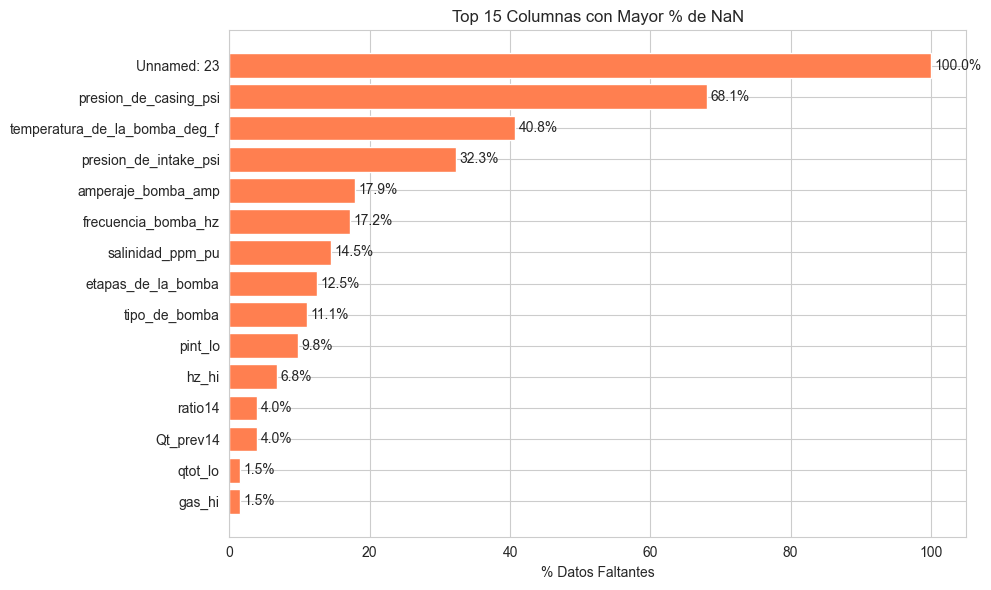

In [ ]:
# Visualización de NaN
if len(missing_df) > 0:
    top_missing = missing_df.head(15)  # Top 15 con más NaN
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_missing['Columna'], top_missing['NaN_pct'], color='coral')
    ax.set_xlabel('% Datos Faltantes')
    ax.set_title('Top 15 Columnas con Mayor % de NaN')
    ax.invert_yaxis()
    for i, v in enumerate(top_missing['NaN_pct']):
        ax.text(v + 0.5, i, f"{v:.1f}%", va='center')
    plt.tight_layout()
    plt.show()
else:
    print("✅ No hay datos faltantes en el dataset")

## 3. Identificación de Variables Clave para Correlación

Nos enfocaremos en variables numéricas de producción y operativas.

In [ ]:
# Variables numéricas clave (originales + derivadas)
VARS_PRODUCCION = [
    'prueba_de_produccion_petróleo_a_24_horas_bbld',
    'prueba_de_producción_agua_a_24_horas_bbld',
    'prueba_pozooil_24__prueba_pozowater_24',  # Q_total
    'prueba_de_producción_gas_a_24_horas_mcfd',
    'bsw_pct'
]

VARS_OPERATIVAS = [
    'frecuencia_bomba_hz',
    'presion_de_intake_psi',
    'amperaje_bomba_amp',
    'presion_de_tubing_psi',
    'presion_de_casing_psi',
    'temperatura_de_la_bomba_deg_f'
]

VARS_DERIVADAS = [
    'slope_7',
    'slope_14',
    'delta_1',
    'delta_3',
    'ratio14'
]

# Filtrar solo las que existen en df
vars_disponibles = [v for v in VARS_PRODUCCION + VARS_OPERATIVAS + VARS_DERIVADAS if v in df.columns]
print(f"Variables numéricas clave disponibles: {len(vars_disponibles)}")
print(vars_disponibles)

Variables numéricas clave disponibles: 16
['prueba_de_produccion_petróleo_a_24_horas_bbld', 'prueba_de_producción_agua_a_24_horas_bbld', 'prueba_pozooil_24__prueba_pozowater_24', 'prueba_de_producción_gas_a_24_horas_mcfd', 'bsw_pct', 'frecuencia_bomba_hz', 'presion_de_intake_psi', 'amperaje_bomba_amp', 'presion_de_tubing_psi', 'presion_de_casing_psi', 'temperatura_de_la_bomba_deg_f', 'slope_7', 'slope_14', 'delta_1', 'delta_3', 'ratio14']


## 4. Matriz de Correlación

Columnas con <80% NaN: 16 de 16


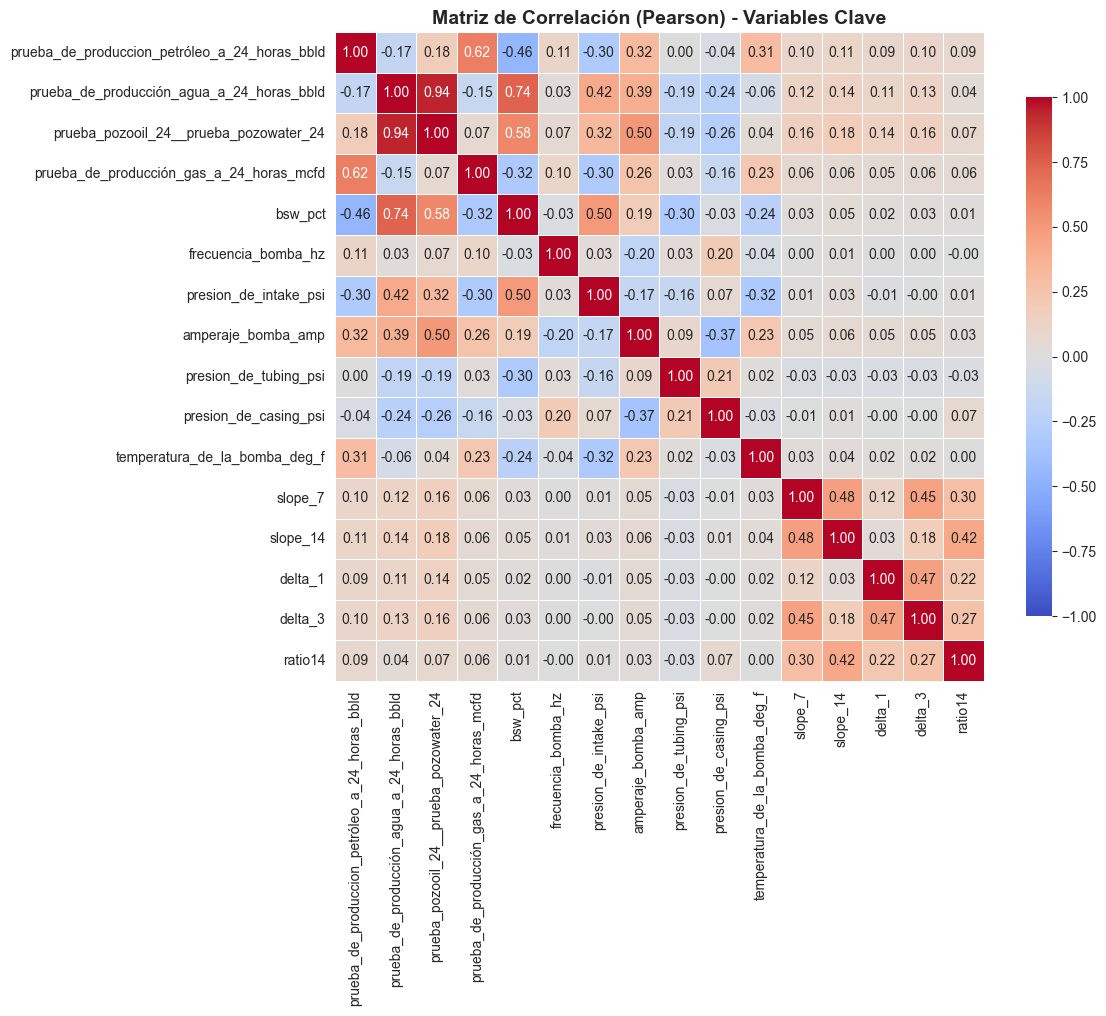

In [ ]:
# Seleccionar solo numéricas sin NaN excesivos (>80%)
df_num = df[vars_disponibles].copy()
nan_pct_per_col = df_num.isnull().mean() * 100
cols_validas = nan_pct_per_col[nan_pct_per_col < 80].index.tolist()

print(f"Columnas con <80% NaN: {len(cols_validas)} de {len(vars_disponibles)}")

# Correlación (Pearson)
corr_matrix = df_num[cols_validas].corr()

# Visualización
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Matriz de Correlación (Pearson) - Variables Clave', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## 5. Correlaciones Más Fuertes (Top 20)

In [ ]:
# Extraer pares de correlación (sin diagonal y sin duplicados)
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]
        if not pd.isna(corr_val):
            corr_pairs.append({
                'Var1': var1,
                'Var2': var2,
                'Correlación': corr_val,
                'Abs_Corr': abs(corr_val)
            })

corr_df = pd.DataFrame(corr_pairs).sort_values('Abs_Corr', ascending=False).head(20)

print("=== TOP 20 CORRELACIONES MÁS FUERTES ===")
print(corr_df[['Var1', 'Var2', 'Correlación']].to_string(index=False))

=== TOP 20 CORRELACIONES MÁS FUERTES ===
                                         Var1                                     Var2  Correlación
    prueba_de_producción_agua_a_24_horas_bbld   prueba_pozooil_24__prueba_pozowater_24         0.94
    prueba_de_producción_agua_a_24_horas_bbld                                  bsw_pct         0.74
prueba_de_produccion_petróleo_a_24_horas_bbld prueba_de_producción_gas_a_24_horas_mcfd         0.62
       prueba_pozooil_24__prueba_pozowater_24                                  bsw_pct         0.58
       prueba_pozooil_24__prueba_pozowater_24                       amperaje_bomba_amp         0.50
                                      bsw_pct                    presion_de_intake_psi         0.50
                                      slope_7                                 slope_14         0.48
                                      delta_1                                  delta_3         0.47
prueba_de_produccion_petróleo_a_24_horas_bbld              

## 6. Análisis de Correlación con Variable Objetivo (pred_evento)

**Importante:** Usamos `pred_evento` (etiquetas robustecidas por rangos operacionales) en lugar de `evento_hibrido` original, ya que filtra ruido externo (paros de luz, manifestaciones, reducciones programadas) y se enfoca en anomalías operativas reales del pozo.

=== CORRELACIÓN CON PRED_EVENTO (binario 0 vs 1+2) ===
                                     Variable  Correlación_con_PredEvento
                                      ratio14                        0.20
                                     slope_14                        0.08
                                      bsw_pct                        0.05
                        presion_de_tubing_psi                       -0.04
                temperatura_de_la_bomba_deg_f                       -0.03
                                      slope_7                        0.02
                           amperaje_bomba_amp                        0.02
                        presion_de_casing_psi                        0.02
     prueba_de_producción_gas_a_24_horas_mcfd                        0.02
                          frecuencia_bomba_hz                       -0.01
prueba_de_produccion_petróleo_a_24_horas_bbld                        0.01
       prueba_pozooil_24__prueba_pozowater_24            

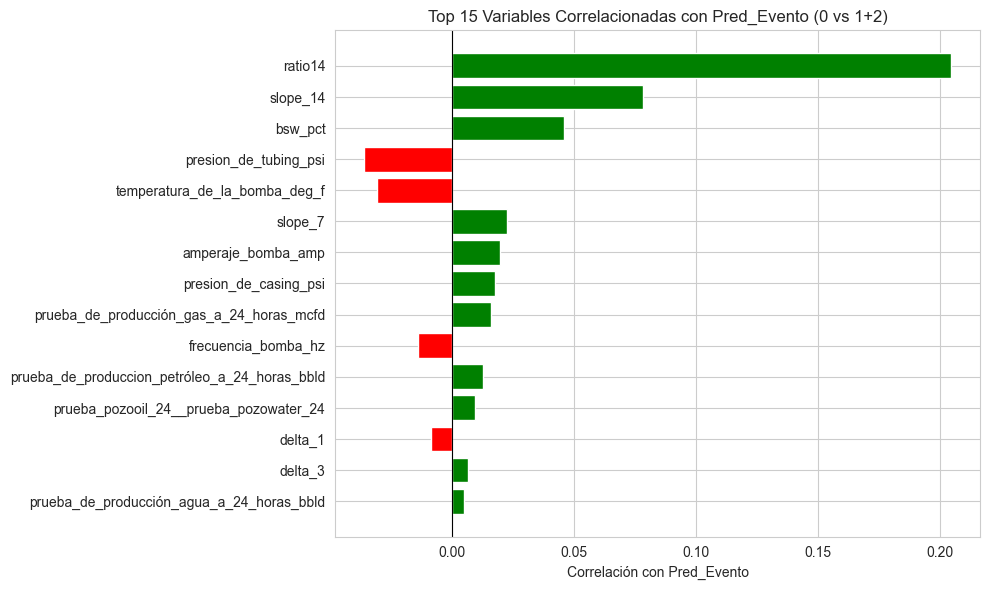

In [ ]:
if 'pred_evento' in df.columns:
    # Correlación punto-biserial (numérica vs categórica binaria)
    pred_bin = df['pred_evento'].fillna(0).astype(int).clip(0, 1)  # 0 vs 1+2
    
    corr_pred = []
    for col in cols_validas:
        if col in df.columns:
            valid_idx = df[col].notna() & pred_bin.notna()
            if valid_idx.sum() > 100:  # Al menos 100 observaciones válidas
                corr_val = df.loc[valid_idx, col].corr(pred_bin[valid_idx])
                corr_pred.append({'Variable': col, 'Correlación_con_PredEvento': corr_val})
    
    corr_pred_df = pd.DataFrame(corr_pred).sort_values('Correlación_con_PredEvento', 
                                                        key=abs, ascending=False)
    
    print("=== CORRELACIÓN CON PRED_EVENTO (binario 0 vs 1+2) ===")
    print(corr_pred_df.head(15).to_string(index=False))
    
    # Visualización
    top_corr_pred = corr_pred_df.head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['green' if x > 0 else 'red' for x in top_corr_pred['Correlación_con_PredEvento']]
    ax.barh(top_corr_pred['Variable'], top_corr_pred['Correlación_con_PredEvento'], color=colors)
    ax.set_xlabel('Correlación con Pred_Evento')
    ax.set_title('Top 15 Variables Correlacionadas con Pred_Evento (0 vs 1+2)')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Columna 'pred_evento' no encontrada")

## 7. Resumen de Datos Faltantes por Tipo de Variable

Clasificaremos variables para estrategias de imputación.

In [ ]:
# Clasificación de variables
resumen_missing = {
    'Producción': [],
    'Operativas': [],
    'Derivadas': [],
    'Otras': []
}

for col in missing_df['Columna']:
    pct = missing_df[missing_df['Columna'] == col]['NaN_pct'].values[0]
    item = f"{col}: {pct:.1f}%"
    
    if col in VARS_PRODUCCION:
        resumen_missing['Producción'].append(item)
    elif col in VARS_OPERATIVAS:
        resumen_missing['Operativas'].append(item)
    elif col in VARS_DERIVADAS:
        resumen_missing['Derivadas'].append(item)
    else:
        resumen_missing['Otras'].append(item)

print("=== RESUMEN DE NaN POR TIPO DE VARIABLE ===")
for tipo, items in resumen_missing.items():
    if items:
        print(f"\n{tipo} ({len(items)}):")
        for item in items:
            print(f"  - {item}")
    else:
        print(f"\n{tipo}: ✅ Sin NaN")

=== RESUMEN DE NaN POR TIPO DE VARIABLE ===

Producción (1):
  - bsw_pct: 0.0%

Operativas (6):
  - presion_de_casing_psi: 68.1%
  - temperatura_de_la_bomba_deg_f: 40.8%
  - presion_de_intake_psi: 32.3%
  - amperaje_bomba_amp: 17.9%
  - frecuencia_bomba_hz: 17.2%
  - presion_de_tubing_psi: 0.2%

Derivadas (5):
  - ratio14: 4.0%
  - slope_14: 1.1%
  - delta_3: 0.8%
  - slope_7: 0.6%
  - delta_1: 0.3%

Otras (11):
  - Unnamed: 23: 100.0%
  - salinidad_ppm_pu: 14.5%
  - etapas_de_la_bomba: 12.5%
  - tipo_de_bomba: 11.1%
  - pint_lo: 9.8%
  - hz_hi: 6.8%
  - Qt_prev14: 4.0%
  - qtot_lo: 1.5%
  - gas_hi: 1.5%
  - qtot_hi: 1.5%
  - gravedad_api_del_petroleo: 0.4%


## 8. Evaluación de Calidad de pred_evento

**Objetivo:** Validar que `pred_evento` (etiquetas robustecidas) capture correctamente anomalías operativas mediante análisis de tendencias con variables de producción y gas.

Esta evaluación es crítica antes de entrenar modelos de ML, ya que `pred_evento` será nuestra variable objetivo.

In [ ]:
# Verificar columnas clave para análisis de tendencias
COL_FECHA = 'date'
COL_POZO = 'name_'
COL_QTOT = 'prueba_pozooil_24__prueba_pozowater_24'
COL_QGAS = 'prueba_de_producción_gas_a_24_horas_mcfd'

# Verificar si las columnas necesarias existen
required_cols = [COL_FECHA, COL_POZO, COL_QTOT, COL_QGAS, 'pred_evento']
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    print(f"⚠️ Columnas faltantes: {missing_cols}")
    print("Columnas disponibles en df:")
    print([c for c in df.columns if 'prueba' in c.lower() or 'name' in c.lower() or 'date' in c.lower() or 'pred' in c.lower()])
    can_continue = False
else:
    print("✅ Todas las columnas necesarias están disponibles")
    can_continue = True

In [ ]:
if can_continue:
    # Análisis de distribución de pred_evento
    print("=== DISTRIBUCIÓN DE PRED_EVENTO ===")
    pred_counts = df['pred_evento'].value_counts().sort_index()
    pred_pct = (pred_counts / len(df) * 100).round(2)

    dist_df = pd.DataFrame({
        'pred_evento': pred_counts.index,
        'Conteo': pred_counts.values,
        'Porcentaje': pred_pct.values
    })

    print(dist_df.to_string(index=False))

    # Visualización de distribución
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Gráfico de barras
    bars = ax1.bar(dist_df['pred_evento'].astype(str), dist_df['Conteo'],
                   color=['green', 'orange', 'red'])
    ax1.set_title('Distribución de pred_evento')
    ax1.set_xlabel('Categoría pred_evento')
    ax1.set_ylabel('Conteo')
    for bar, pct in zip(bars, dist_df['Porcentaje']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{pct:.1f}%', ha='center', va='bottom')

    # Gráfico circular
    ax2.pie(dist_df['Porcentaje'], labels=[f'{v}\n{pct:.1f}%' for v, pct in zip(dist_df['pred_evento'], dist_df['Porcentaje'])],
            colors=['green', 'orange', 'red'], autopct='%1.1f%%', startangle=90)
    ax2.set_title('Distribución porcentual')

    plt.tight_layout()
    plt.show()

In [ ]:
    # Análisis de tendencias: Comparación de producción por grupos pred_evento
 print("\n=== ANÁLISIS DE TENDENCIAS POR PRED_EVENTO ===")

    # Estadísticas descriptivas por grupo
    trend_vars = [COL_QTOT, COL_QGAS]
    available_trend_vars = [v for v in trend_vars if v in df.columns]

    if available_trend_vars:
        trend_stats = df.groupby('pred_evento')[available_trend_vars].agg(['mean', 'median', 'std', 'count']).round(2)
        print("Estadísticas de producción por grupo pred_evento:")
        print(trend_stats.to_string())

        # Visualización comparativa
        fig, axes = plt.subplots(1, len(available_trend_vars), figsize=(15, 6))

        if len(available_trend_vars) == 1:
            axes = [axes]

        for i, var in enumerate(available_trend_vars):
            # Boxplot
            data_to_plot = [df[df['pred_evento'] == cat][var].dropna() for cat in sorted(df['pred_evento'].unique())]
            axes[i].boxplot(data_to_plot, labels=sorted(df['pred_evento'].unique()))
            axes[i].set_title(f'Distribución de {var.split("_")[-2] if "prueba" in var else var}')
            axes[i].set_ylabel(var.split("_")[-2] if "prueba" in var else var)
            axes[i].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

In [ ]:
    # Validación cuantitativa: Separación entre grupos
    print("\n=== VALIDACIÓN CUANTITATIVA DE PRED_EVENTO ===")

    # Test estadístico: diferencia significativa entre grupos
    from scipy import stats

    validation_results = []
    for var in available_trend_vars:
        groups = [df[df['pred_evento'] == cat][var].dropna() for cat in sorted(df['pred_evento'].unique())]
        groups = [g for g in groups if len(g) > 10]  # Solo grupos con suficientes datos

        if len(groups) >= 2:
            # ANOVA si 3+ grupos, t-test si 2 grupos
            if len(groups) == 2:
                stat, p_val = stats.ttest_ind(groups[0], groups[1])
                test_name = "t-test"
            else:
                stat, p_val = stats.f_oneway(*groups)
                test_name = "ANOVA"

            validation_results.append({
                'Variable': var,
                'Test': test_name,
                'Estadístico': round(stat, 3),
                'p-valor': round(p_val, 4),
                'Significativo': 'Sí' if p_val < 0.05 else 'No'
            })

    if validation_results:
        val_df = pd.DataFrame(validation_results)
        print("Resultados de pruebas estadísticas:")
        print(val_df.to_string(index=False))

        # Visualización de significancia
        fig, ax = plt.subplots(figsize=(10, 6))
        colors = ['red' if p < 0.05 else 'gray' for p in val_df['p-valor']]
        bars = ax.barh(val_df['Variable'], -np.log10(val_df['p-valor']), color=colors)
        ax.axvline(-np.log10(0.05), color='red', linestyle='--', alpha=0.7, label='p = 0.05')
        ax.set_xlabel('-log10(p-valor)')
        ax.set_title('Significancia Estadística: Separación entre Grupos pred_evento')
        ax.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
    # Análisis específico: Distribución de gas por pred_evento
    print("\n=== ANÁLISIS ESPECÍFICO: DISTRIBUCIÓN DE GAS ===")

    if COL_QGAS in df.columns:
        # Estadísticas de gas por grupo
        gas_stats = df.groupby('pred_evento')[COL_QGAS].describe().round(2)
        print("Estadísticas de producción de gas por pred_evento:")
        print(gas_stats)

        # Visualización de densidad de gas
        fig, ax = plt.subplots(figsize=(10, 6))

        for cat in sorted(df['pred_evento'].unique()):
            data = df[df['pred_evento'] == cat][COL_QGAS].dropna()
            if len(data) > 10:
                sns.kdeplot(data, label=f'pred_evento = {cat}', ax=ax, fill=True, alpha=0.3)

        ax.set_xlabel('Producción de Gas (MCFD)')
        ax.set_ylabel('Densidad')
        ax.set_title('Distribución de Producción de Gas por Categoría pred_evento')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Scatter plot: Gas vs Producción total coloreado por pred_evento
        fig, ax = plt.subplots(figsize=(10, 6))

        scatter = ax.scatter(df[COL_QTOT], df[COL_QGAS],
                           c=df['pred_evento'], cmap='viridis',
                           alpha=0.6, s=30)

        ax.set_xlabel('Producción Total (Aceite + Agua)')
        ax.set_ylabel('Producción de Gas (MCFD)')
        ax.set_title('Relación Gas vs Producción Total por pred_evento')
        ax.grid(True, alpha=0.3)

        # Leyenda
        legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                    markerfacecolor=scatter.cmap(scatter.norm(cat)),
                                    markersize=8, label=f'pred_evento = {cat}')
                         for cat in sorted(df['pred_evento'].unique())]
        ax.legend(handles=legend_elements)

        plt.tight_layout()
        plt.show()

print("\n" + "="*60)
print("✅ EVALUACIÓN DE PRED_EVENTO COMPLETADA")
print("="*60)
print("\nResumen de hallazgos:")
print("- Distribución de categorías pred_evento analizada")
print("- Tendencias de producción validadas estadísticamente")
print("- Separación entre grupos evaluada")
print("- Análisis específico de gas completado")
print("\nPróximo paso: Imputación de datos faltantes basada en estos insights")